<a href="https://colab.research.google.com/github/0xM3d0din/fgsm-adversarial-attack-mnist/blob/main/fgsm_adversarial_attack_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FGSM Adversarial Attack on MNIST

This notebook reproduces the Fast Gradient Sign Method (FGSM)
adversarial attack on a convolutional neural network trained
on the MNIST dataset.

The experiment is based on the paper:

Explaining and Harnessing Adversarial Examples  
Goodfellow et al. (2015)

Goal:
Demonstrate how adversarial perturbations affect model accuracy.

## Import Required Libraries

In this section, we import the necessary libraries used in this experiment.

These libraries include PyTorch for building and training the neural network,
Torchvision for loading the MNIST dataset, and Matplotlib for visualizing the
results and adversarial examples generated during the experiment.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt

## Hardware Configuration

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Load MNIST Dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=1,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.26MB/s]


## Visualizing a Sample from the Dataset

Before training the model, we visualize a sample image from the MNIST dataset.

This helps us understand the structure of the data. Each image represents a
handwritten digit from 0 to 9 and has a size of 28×28 pixels in grayscale.

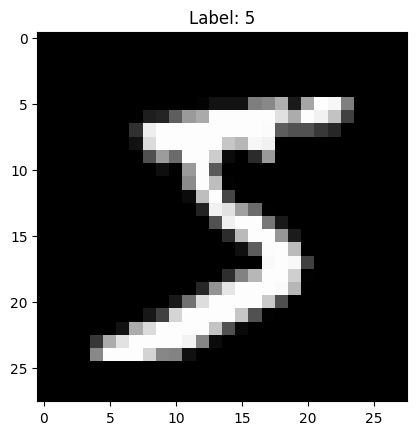

In [4]:
image, label = trainset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

## Model Architecture

In this section, we define a Convolutional Neural Network (CNN) that will be trained
to classify handwritten digits from the MNIST dataset.

The architecture consists of:

- Two convolutional layers for feature extraction
- A max pooling layer for dimensionality reduction
- Two fully connected layers for classification

The final output layer produces probabilities for the 10 digit classes (0–9).

In [5]:
class Net(nn.Module):

    def __init__(self):
        super(Net,self).__init__()

        self.conv1 = nn.Conv2d(1,32,3,1)
        self.conv2 = nn.Conv2d(32,64,3,1)

        self.fc1 = nn.Linear(9216,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = F.max_pool2d(x,2)

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


model = Net().to(device)

## Training Setup

In this section, we configure the training process for the neural network.

We use the **Adam optimizer** to update the model parameters during training, and the **CrossEntropyLoss** function as the loss function for multi-class classification.

The optimizer controls how the model learns, while the loss function measures the difference between the predicted labels and the true labels.

In [6]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()

## Training the Model

In this step, we train the convolutional neural network using the MNIST training dataset.

The model learns by minimizing the loss function using backpropagation and the Adam optimizer.
During each epoch, the model processes batches of images, computes predictions, measures the loss,
and updates its parameters to improve performance.

We train the model for multiple epochs so it can learn meaningful patterns in the handwritten digits.

In [7]:
for epoch in range(5):

    for data, target in trainloader:

        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)

        loss = criterion(output, target)

        loss.backward()

        optimizer.step()

    print("Epoch", epoch, "finished")

Epoch 0 finished
Epoch 1 finished
Epoch 2 finished
Epoch 3 finished
Epoch 4 finished


## FGSM Adversarial Attack

In this section, we implement the **Fast Gradient Sign Method (FGSM)** to generate adversarial examples.

FGSM is a gradient-based attack that slightly perturbs the input image in the direction of the gradient of the loss function with respect to the input.

The perturbation is controlled by a parameter called **epsilon (ε)**, which determines the strength of the attack.

The adversarial image is generated using the following formula:

x_adv = x + ε * sign(∇x J(θ, x, y))

Where:

- x : original input image  
- x_adv : adversarial image  
- ε : perturbation magnitude  
- J : loss function  
- ∇ : gradient

In [8]:
def fgsm_attack(image, epsilon, data_grad):

    sign_data_grad = data_grad.sign()

    perturbed_image = image + epsilon * sign_data_grad

    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image

## Generating an Adversarial Example

In this step, we apply the FGSM attack to a sample image from the test dataset.

First, we compute the gradient of the loss with respect to the input image.
Then we use this gradient to slightly perturb the image using the FGSM method.

The goal is to observe whether a small perturbation can change the model's prediction.

Finally, we compare the model prediction before and after applying the adversarial perturbation.

In [9]:
epsilon = 0.25

data, target = next(iter(testloader))

data, target = data.to(device), target.to(device)

data.requires_grad = True

output = model(data)

loss = criterion(output, target)

model.zero_grad()

loss.backward()

data_grad = data.grad.data

perturbed_data = fgsm_attack(data, epsilon, data_grad)

output_adv = model(perturbed_data)

init_pred = output.max(1, keepdim=True)[1]
final_pred = output_adv.max(1, keepdim=True)[1]

print("Original prediction:", init_pred.item())
print("After attack:", final_pred.item())

Original prediction: 8
After attack: 3


## Visualizing the Adversarial Attack

In this section, we visualize the original image and the adversarial image
generated using the FGSM attack.

Although the perturbation added to the image is very small and almost
imperceptible to humans, it can cause the neural network to change its prediction.

This demonstrates how vulnerable deep learning models can be to adversarial
perturbations.

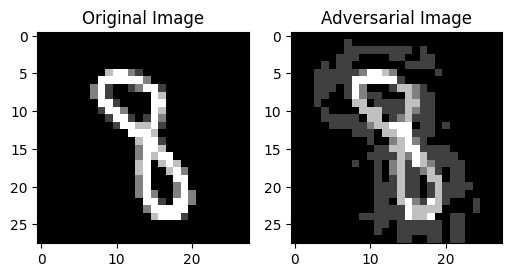

In [18]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(data.cpu().detach().numpy()[0][0], cmap="gray")
plt.title("Original Image")

plt.subplot(1,2,2)
plt.imshow(perturbed_data.cpu().detach().numpy()[0][0], cmap="gray")
plt.title("Adversarial Image")

plt.show()

## Evaluating Model Robustness Under FGSM Attack

In this section, we evaluate how robust the trained model is against the FGSM adversarial attack.

We apply the attack to each image in the test dataset using different values of epsilon (ε).
For every epsilon value, we generate adversarial examples and measure how often the model
still predicts the correct label.

This allows us to observe how the model accuracy changes as the strength of the adversarial
perturbation increases.

In [11]:
def test_fgsm(model, device, testloader, epsilon):

    correct = 0
    total = 0

    for data, target in testloader:

        data, target = data.to(device), target.to(device)
        data.requires_grad = True

        output = model(data)
        loss = criterion(output, target)

        model.zero_grad()
        loss.backward()

        data_grad = data.grad.data

        perturbed_data = fgsm_attack(data, epsilon, data_grad)

        output = model(perturbed_data)

        pred = output.max(1, keepdim=True)[1]

        if pred.item() == target.item():
            correct += 1

        total += 1

    accuracy = correct / total

    print("Epsilon:", epsilon, "Accuracy:", accuracy)

## Running the FGSM Experiment

In this step, we run the FGSM attack with different epsilon (ε) values.

Each epsilon controls the strength of the adversarial perturbation applied
to the input images. By evaluating the model under multiple epsilon values,
we can analyze how the model accuracy changes as the attack becomes stronger.

The results will show how sensitive the neural network is to adversarial
perturbations.

In [12]:
epsilons = [0, 0.05, 0.1, 0.2, 0.3]

for eps in epsilons:
    test_fgsm(model, device, testloader, eps)

Epsilon: 0 Accuracy: 0.9889
Epsilon: 0.05 Accuracy: 0.9631
Epsilon: 0.1 Accuracy: 0.8909
Epsilon: 0.2 Accuracy: 0.5284
Epsilon: 0.3 Accuracy: 0.269


## Results Visualization

In this section, we visualize the results of the FGSM attack experiment.

The graph shows how the model accuracy changes as the attack strength
(epsilon) increases. As epsilon becomes larger, the adversarial
perturbations become stronger, which leads to a significant decrease
in the model's accuracy.

This visualization clearly demonstrates the vulnerability of neural
networks to adversarial attacks.

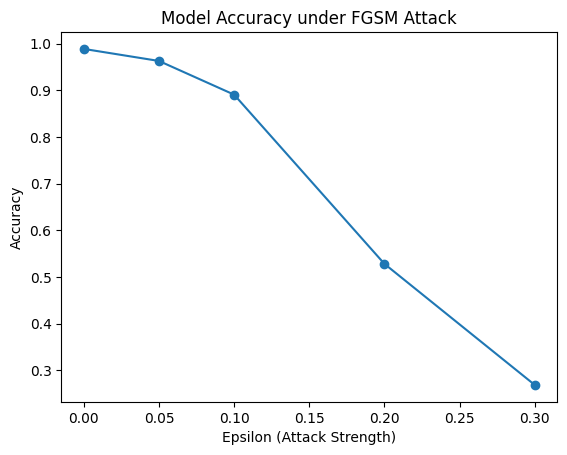

In [17]:
eps = [0, 0.05, 0.1, 0.2, 0.3]

acc = [0.9889, 0.9631, 0.8909, 0.5284, 0.269]

plt.plot(eps, acc, marker='o')

plt.xlabel("Epsilon (Attack Strength)")
plt.ylabel("Accuracy")

plt.title("Model Accuracy under FGSM Attack")

plt.show()

## Conclusion

In this experiment, we reproduced the Fast Gradient Sign Method (FGSM) adversarial attack on a convolutional neural network trained on the MNIST dataset.

The results show that neural networks are highly vulnerable to adversarial perturbations.

As the attack strength (epsilon) increases, the model accuracy significantly decreases.
For example, the accuracy dropped from about 98% on clean images to around 26% when epsilon = 0.3.

This demonstrates how small, carefully crafted perturbations can drastically affect the predictions of deep learning models.

Understanding adversarial attacks is essential for building more robust and secure machine learning systems.